# Problemas de Estadística Descriptiva

## Ejercicio 1 – ¿Qué tan largos son los títulos de las películas?

En este ejercicio vas a aplicar técnicas de estadística descriptiva sobre un conjunto de datos real: una base con 1000 películas populares del sitio IMDb.

A partir del título de cada película, vas a:
- Calcular la longitud del título (en caracteres).
- Obtener métricas estadísticas clave: media, mediana, moda, rango, varianza, desviación estándar, asimetría y curtosis.
- Identificar los títulos más largos y más cortos.
- Visualizar la distribución de estas longitudes con un histograma y una curva de densidad.


In [7]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, mode

# Cargar dataset de IMDb
url = "../assets/imdb_1000.csv"
df = pd.read_csv(url)
df

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


In [10]:
df['title'].unique()

<StringArray>
[                       'The Shawshank Redemption',
                                   'The Godfather',
                          'The Godfather: Part II',
                                 'The Dark Knight',
                                    'Pulp Fiction',
                                    '12 Angry Men',
                  'The Good, the Bad and the Ugly',
   'The Lord of the Rings: The Return of the King',
                                'Schindler's List',
                                      'Fight Club',
 ...
                             'Law Abiding Citizen',
                                     'Wonder Boys',
                              'Death at a Funeral',
                                  'Blue Valentine',
                           'The Cider House Rules',
                                         'Tootsie',
                     'Back to the Future Part III',
 'Master and Commander: The Far Side of the World',
                                     'Polterg

In [12]:
# Crea una nueva columna llamada 'title_length' con la longitud (número de caracteres) de cada título
df['title_length'] = df['title'].str.len()
df

,star_rating,title,content_rating,genre,duration,actors_list,title_length
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt...",24
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']",13
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv...",22
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E...",15
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L....",12
...,...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G...",7
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma...",27
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo...",47
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr...",11


In [20]:
# Calcula media, mediana y moda de la columna 'title_length'
print (f'La mediana de caracteres de los titulos es:',df['title_length'].median())
print (f'La media de caracteres de los titulos es:',round(df['title_length'].mean(),2))
print (f'La moda de los caracteres de los titulos es:', df['title_length'].mode())

La mediana de caracteres de los titulos es: 14.0
La media de caracteres de los titulos es: 15.48
La moda de los caracteres de los titulos es: 0    12
Name: title_length, dtype: int64


In [35]:
# Calcula el rango, la varianza y la desviación estándar de 'title_length'
rango = df['title_length'].max() - df['title_length'].min()
print ('El rango es:',rango)

varianza = df['title_length'].var()
print ('La varianza es:', varianza)

desviacion_estandar = df['title_length'].std()
print ('La desviacion estandar es:', desviacion_estandar)



El rango es: 67
La varianza es: 72.1067488840288
La desviacion estandar es: 8.491569282766807


In [36]:
# Calcula asimetría y curtosis de la columna 'title_length'
asimetria = df['title_length'].skew()
print ('La asimetria es:', asimetria)

curtosis = df['title_length'].kurt()
print ('La curtosis es:', curtosis)

La asimetria es: 1.5252523464631278
La curtosis es: 3.8122887061291544


In [38]:
# Imprime el título más corto y el título más largo según su longitud
titulo_mas_corto = df.loc[df["title_length"].idxmin(), "title"]
titulo_mas_largo = df.loc[df["title_length"].idxmax(), "title"]

print(f"Título más corto: {titulo_mas_corto}")
print(f"Título más largo: {titulo_mas_largo}")

Título más corto: M
Título más largo: Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb


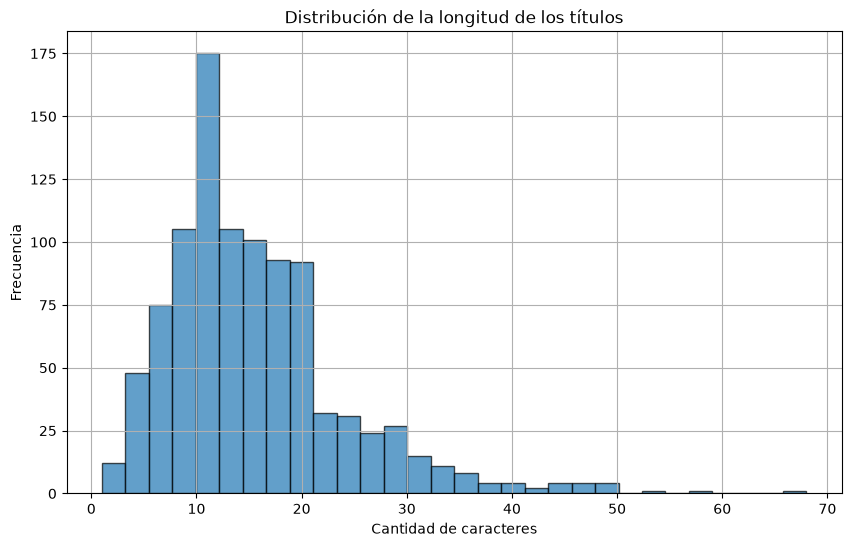

In [41]:
# grafica tus resultados
plt.figure(figsize=(10, 6))
plt.hist(df["title_length"], bins=30, edgecolor='black', alpha=0.7)
plt.title("Distribución de la longitud de los títulos")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

---

## Ejercicio 2 – Cálculo manual de desviación estándar

En este ejercicio vas a calcular manualmente la desviación estándar, seleccionando cinco títulos reales del dataset de películas que cargaste antes.


In [46]:
# Crea una lista con 5 valores reales de df['title_length'], por ejemplo: [10, 13, 14, 18, 22]
data = df['title_length'].head()
data

0    24
1    13
2    22
3    15
4    12
Name: title_length, dtype: int64

In [48]:
# Calcula la media de los 5 valores
media_data = sum(data)/len(data)
print('La media de la data es:', media_data)

La media de la data es: 17.2


In [50]:
# Calcula las diferencias al cuadrado con respecto a la media
suma_diferencias = sum((x - media_data)**2 for x in data)
print ('La suma de diferencias al cuadrado es:', suma_diferencias)

La suma de diferencias al cuadrado es: 118.80000000000001


In [52]:
# Calcula la varianza (promedio de las diferencias al cuadrado) y su raíz cuadrada para obtener la desviación
varianza = suma_diferencias/len(data)
print('La varianza es:', varianza)

desviacion_estandar = varianza**0.5
print('La desviacion estandar es:', desviacion_estandar)

La varianza es: 23.76
La desviacion estandar es: 4.874423042781577
